## Title: "Chapter 4 HW"
### Author: "Makenna Worley"
### Date: "10/20/2025"

In [2]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn

#### (5a) If the Bayes decision boundary is linear, do we expect LDA or QDA to perform better on the training set? On the test set?

Training set: QDA should be better because it is more flexible than LDA. Especially if the data is truly able to be separated linearly.

Testing set: LDA because it is less flexible (lower variance) than QDA. QDA has extra flexibility that could increase the variance or overfit.

#### (5b) If the Bayes decision boundary is non-linear, do we expect LDA or QDA to perform better on the training set? On the test set?

Training set: QDA because the boundary line is non-linear, meaning LDA will struggle.

Testing set: QDA because the boundary line is non-linear and thus we need the flexibility of a non-linear boundary but could overfit if the dataset is small.

#### (5c) In general, as the sample size n increases, do we expect the test prediction accuracy of QDA relative to LDA to improve, decline, or be unchanged? Why?

As n increases, the variance decreases and the bias increases, so less prone to overfitting. So the accuracy increases as n increases compared to LDA.

#### (5d) True or False: Even if the Bayes decision boundary for a given problem is linear, we will probably achieve a superior test error rate using QDA rather than LDA because QDA is flexible enough to model a linear decision boundary. Justify your answer.

False, QDA can do a linear boundary but it is much more flexible than a LDA meaning it could be worse. So if the boundary is truly linear, it would be better to use LDA instead of QDA.

#### (6a) Estimate the probability that a student who studies for 40 h and has an undergrad GPA of 3.5 gets an A in the class.

$$P(Y = 1 | x) = \frac{1}{1+ exp\{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2)\}}$$

$$P(Y = 1 | x) = \frac{1}{1 + exp\{-(-6 + .05 x_1 + 1 x_2)\}} = \frac{1}{1 + e^{0.5}} \approx .378$$

About a 37.8 chance of an A

#### (6b) How many hours would the student in part (a) need to study to have a 50 % chance of getting an A in the class?

$$0 = -6 + .05 x_1 + 3.5$$

$$0.05h = 2.5$$

$$\frac{2.5}{0.05} = 50$$

About 50 hours of studying yields a 50% chance of an A given GPA is 3.5

#### (8) Suppose that we take a data set, divide it into equally-sized training and test sets, and then try out two different classification procedures. First we use logistic regression and get an error rate of 20 % on the training data and 30 % on the test data. Next we use 1-nearest neighbors (i.e. K = 1) and get an average error rate (averaged over both test and training data sets) of 18 %. Based on these results, which method should we prefer to use for classification of new observations? Why?

The training and test errors are really close meaning that there low variance and some bias, so the model generates well.

K = 1, means there is little error for the training data but that means there is a lot of testing error. This implies overfitting (aka the predictions are struggling much more than expected thanks to overfitting)

The goal is to get good performance on new data meaning the testing sets. So because the logistic regression has lower testing error, it is better.

#### (13a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [4]:
try:
    from ISLP import load_data
    Weekly = load_data('Weekly')
except Exception:
    url = "https://raw.githubusercontent.com/introstatlearning/ISLP/main/data/Weekly.csv"
    Weekly = pd.read_csv(url)

Weekly.head()
Weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


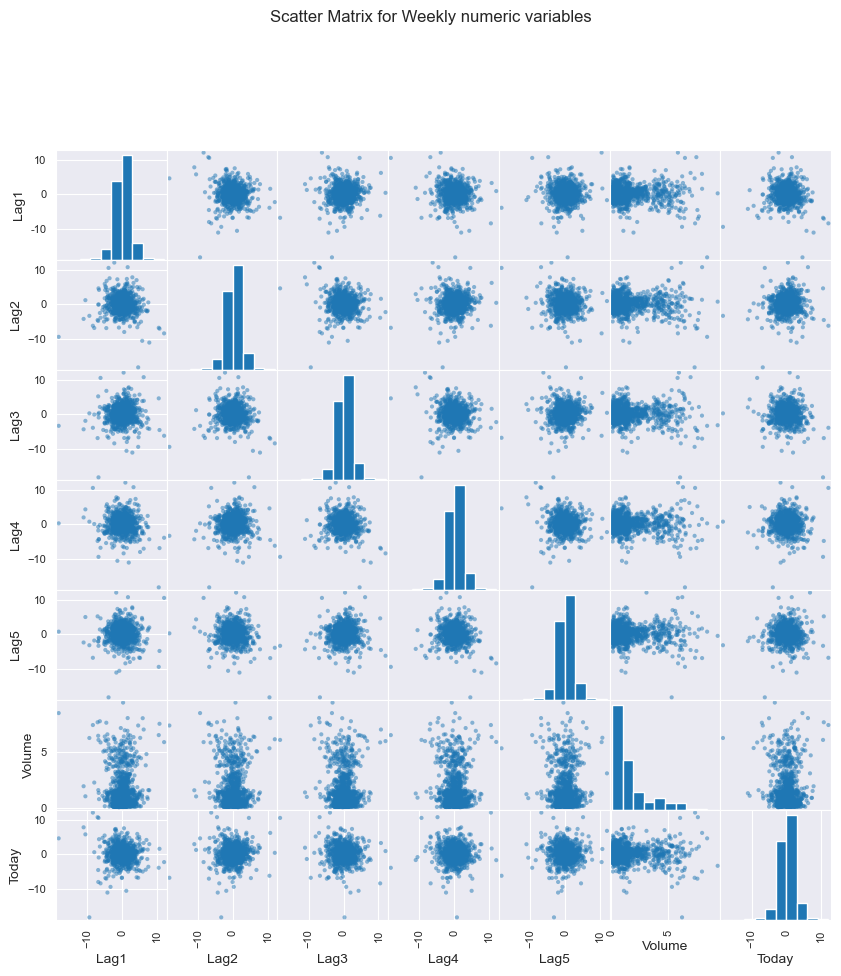

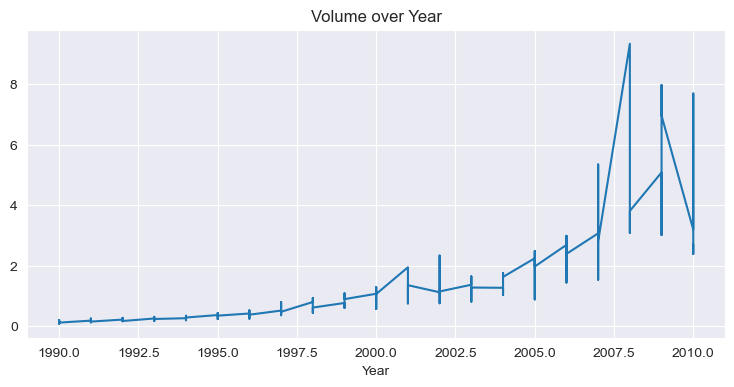

Direction
Up      0.555556
Down    0.444444
Name: proportion, dtype: float64


In [5]:
num_cols = Weekly.select_dtypes(include=[np.number])
print(num_cols.corr())

pd.plotting.scatter_matrix(num_cols[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']],
                           figsize=(10,10))
plt.suptitle("Scatter Matrix for Weekly numeric variables", y=1.02)
plt.show()

Weekly.sort_values('Year').plot(x='Year', y='Volume', kind='line', figsize=(9,4), legend=False)
plt.title('Volume over Year')
plt.show()

print(Weekly['Direction'].value_counts(normalize=True))

The volume increase over time, there doesn't seem to be any correlations between lagged returns and today's returns

#### (13b) Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [6]:
y_bin = (Weekly['Direction'] == 'Up').astype(int)

X_full = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X_full = sm.add_constant(X_full)
logit_full = sm.Logit(y_bin, X_full).fit(disp=False)
print(logit_full.summary())

                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                0.006580
Time:                        11:18:45   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.0

Only lag2 is significiant at p $\approx$ 0.003

#### (13c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

probs_full = logit_full.predict(X_full)
pred_full = (probs_full > 0.5).astype(int)   # 1=Up, 0=Down

cm_full = confusion_matrix(y_bin, pred_full, labels=[0,1])
acc_full = accuracy_score(y_bin, pred_full)

print("Confusion matrix (full data):\n", cm_full)
print("Accuracy (full data):", acc_full)

Confusion matrix (full data):
 [[ 54 430]
 [ 48 557]]
Accuracy (full data): 0.5610651974288338


In [8]:
train_mask = Weekly['Year'] < 2009
test_mask  = ~train_mask

Weekly_train = Weekly.loc[train_mask].copy()
Weekly_test  = Weekly.loc[test_mask].copy()

y_train = (Weekly_train['Direction'] == 'Up').astype(int)
y_test  = (Weekly_test['Direction']  == 'Up').astype(int)

The training accuracy is .561

#### (13d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [9]:
Xtr = sm.add_constant(Weekly_train[['Lag2']])
Xte = sm.add_constant(Weekly_test[['Lag2']])

logit_lag2 = sm.Logit(y_train, Xtr).fit(disp=False)
probs_te = logit_lag2.predict(Xte)
pred_te  = (probs_te > 0.5).astype(int)

cm = confusion_matrix(y_test, pred_te, labels=[0,1])
acc = accuracy_score(y_test, pred_te)

print(logit_lag2.summary())
print("Confusion matrix (Logit, Lag2, 2009–2010 test):\n", cm)
print("Test accuracy (Logit, Lag2):", acc)

                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                0.003076
Time:                        11:21:25   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114
Confusion matrix (Logit, Lag2, 2009–2010 test):
 [[ 

Lag2 has .625 test accuracy

#### (13e) Repeat (d) using LDA.

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA()
lda.fit(Weekly_train[['Lag2']], y_train)
pred_lda = lda.predict(Weekly_test[['Lag2']])

cm_lda = confusion_matrix(y_test, pred_lda, labels=[0,1])
acc_lda = accuracy_score(y_test, pred_lda)
print("Confusion matrix (LDA, Lag2):\n", cm_lda)
print("Test accuracy (LDA, Lag2):", acc_lda)

Confusion matrix (LDA, Lag2):
 [[ 9 34]
 [ 5 56]]
Test accuracy (LDA, Lag2): 0.625


Lag2 has .625 test accuracy

#### (13f) Repeat (d) using QDA.

In [12]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

qda = QDA()
qda.fit(Weekly_train[['Lag2']], y_train)
pred_qda = qda.predict(Weekly_test[['Lag2']])

cm_qda = confusion_matrix(y_test, pred_qda, labels=[0,1])
acc_qda = accuracy_score(y_test, pred_qda)
print("Confusion matrix (QDA, Lag2):\n", cm_qda)
print("Test accuracy (QDA, Lag2):", acc_qda)

Confusion matrix (QDA, Lag2):
 [[ 0 43]
 [ 0 61]]
Test accuracy (QDA, Lag2): 0.5865384615384616


Lag2 has .586 test accuracy

#### (13g) Repeat (d) using KNN with K = 1.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(Weekly_train[['Lag2']], y_train)
pred_knn1 = knn1.predict(Weekly_test[['Lag2']])

cm_knn1 = confusion_matrix(y_test, pred_knn1, labels=[0,1])
acc_knn1 = accuracy_score(y_test, pred_knn1)
print("Confusion matrix (KNN, k=1, Lag2):\n", cm_knn1)
print("Test accuracy (KNN, k=1, Lag2):", acc_knn1)

Confusion matrix (KNN, k=1, Lag2):
 [[21 22]
 [30 31]]
Test accuracy (KNN, k=1, Lag2): 0.5


Lag2 has .5 test accuracy

#### (13h) Repeat (d) using naive Bayes.

In [14]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(Weekly_train[['Lag2']], y_train)
pred_nb = nb.predict(Weekly_test[['Lag2']])

cm_nb = confusion_matrix(y_test, pred_nb, labels=[0,1])
acc_nb = accuracy_score(y_test, pred_nb)
print("Confusion matrix (Naive Bayes, Lag2):\n", cm_nb)
print("Test accuracy (Naive Bayes, Lag2):", acc_nb)

Confusion matrix (Naive Bayes, Lag2):
 [[ 0 43]
 [ 0 61]]
Test accuracy (Naive Bayes, Lag2): 0.5865384615384616


Lag2 has .586 test accuracy

#### (13i) Which of these methods appears to provide the best results on this data?

In [15]:
results = pd.DataFrame({
    'Method': ['Logistic (Lag2)', 'LDA (Lag2)', 'QDA (Lag2)', 'KNN k=1 (Lag2)', 'Naive Bayes (Lag2)'],
    'TestAccuracy': [acc, acc_lda, acc_qda, acc_knn1, acc_nb]
}).sort_values('TestAccuracy', ascending=False)
print(results)

               Method  TestAccuracy
0     Logistic (Lag2)      0.625000
1          LDA (Lag2)      0.625000
2          QDA (Lag2)      0.586538
4  Naive Bayes (Lag2)      0.586538
3      KNN k=1 (Lag2)      0.500000


The best would be logisitic or LDA

#### (13j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

In [16]:
from sklearn.linear_model import LogisticRegression

X_train = Weekly_train[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X_test  = Weekly_test[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]

logr = LogisticRegression(max_iter=1000)
logr.fit(X_train, y_train)
pred = logr.predict(X_test)
print("LogReg (all lags + Volume) test acc:", accuracy_score(y_test, pred))

X_train_int = Weekly_train[['Lag1','Lag2']].copy()
X_train_int['Lag1_Lag2'] = Weekly_train['Lag1'] * Weekly_train['Lag2']
X_test_int = Weekly_test[['Lag1','Lag2']].copy()
X_test_int['Lag1_Lag2'] = Weekly_test['Lag1'] * Weekly_test['Lag2']

logr2 = LogisticRegression(max_iter=1000)
logr2.fit(X_train_int, y_train)
pred2 = logr2.predict(X_test_int)
print("LogReg (Lag1, Lag2, Lag1*Lag2) test acc:", accuracy_score(y_test, pred2))

acc_grid = []
for k in [1,3,5,7,9,11,15,21]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Weekly_train[['Lag2']], y_train)
    acc_k = accuracy_score(y_test, knn.predict(Weekly_test[['Lag2']]))
    acc_grid.append((k, acc_k))
pd.DataFrame(acc_grid, columns=['k','TestAccuracy']).sort_values('TestAccuracy', ascending=False)

LogReg (all lags + Volume) test acc: 0.46153846153846156
LogReg (Lag1, Lag2, Lag1*Lag2) test acc: 0.5769230769230769


,k,TestAccuracy
6,15,0.586538
1,3,0.557692
5,11,0.557692
7,21,0.557692
3,7,0.548077
4,9,0.548077
2,5,0.528846
0,1,0.500000


Adding Lag1 or increasing K helps but does surpass .625 that Log Regression or LDA gets

#### (13k) Show all ROC curves of logistic model, LDA, QDA, KNN, and Naive Bayes in a single graph like this one.

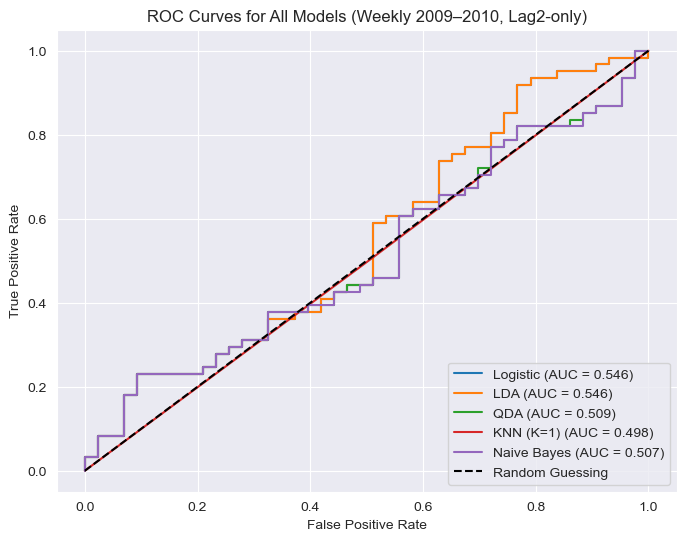

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import statsmodels.api as sm
X_train_lag2 = sm.add_constant(Weekly_train[['Lag2']], has_constant='add')
X_test_lag2  = sm.add_constant(Weekly_test[['Lag2']],  has_constant='add')

logit_lag2 = sm.Logit(y_train, X_train_lag2).fit(disp=False)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

lda = LDA().fit(Weekly_train[['Lag2']], y_train)
qda = QDA().fit(Weekly_train[['Lag2']], y_train)
knn1 = KNeighborsClassifier(n_neighbors=1).fit(Weekly_train[['Lag2']], y_train)
nb  = GaussianNB().fit(Weekly_train[['Lag2']], y_train)

probs_log = logit_lag2.predict(X_test_lag2)
probs_lda = lda.predict_proba(Weekly_test[['Lag2']])[:, 1]
probs_qda = qda.predict_proba(Weekly_test[['Lag2']])[:, 1]
probs_knn = knn1.predict_proba(Weekly_test[['Lag2']])[:, 1]
probs_nb  = nb.predict_proba(Weekly_test[['Lag2']])[:, 1]

models = {
    "Logistic": probs_log,
    "LDA": probs_lda,
    "QDA": probs_qda,
    "KNN (K=1)": probs_knn,
    "Naive Bayes": probs_nb
}

plt.figure(figsize=(8,6))
auc_scores = {}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    auc_scores[name] = auc
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.title("ROC Curves for All Models (Weekly 2009–2010, Lag2-only)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### (13l) Rank these models based on their AUC values.

In [23]:
ranked = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)
print("\nModel Ranking by AUC:")
for i, (name, auc) in enumerate(ranked, 1):
    print(f"{i}. {name} — AUC = {auc:.3f}")


Model Ranking by AUC:
1. Logistic — AUC = 0.546
2. LDA — AUC = 0.546
3. QDA — AUC = 0.509
4. Naive Bayes — AUC = 0.507
5. KNN (K=1) — AUC = 0.498


The best is the logistic and LDA

#### (14a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows: Auto['mpg01 '] = mpg01

In [24]:
try:
    from ISLP import load_data
    Auto = load_data('Auto')
except Exception:
    url = "https://raw.githubusercontent.com/introstatlearning/ISLP/main/data/Auto.csv"
    Auto = pd.read_csv(url)

# Clean horsepower if it's object in some mirrors
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna().reset_index(drop=True)

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [25]:
mpg_median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)
mpg_median, Auto['mpg01'].value_counts(normalize=True)

(22.75,
 mpg01
 0    0.5
 1    0.5
 Name: proportion, dtype: float64)

#### (14b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

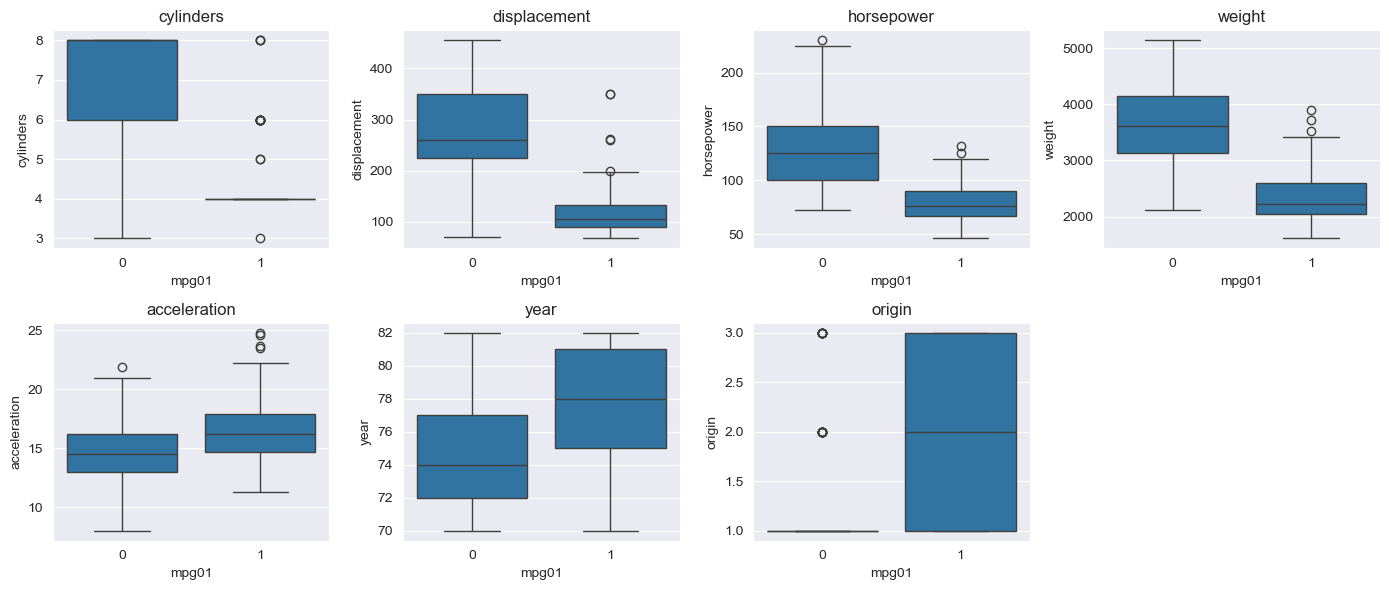

origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
dtype: float64

In [26]:
num_cols = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']

fig, axes = plt.subplots(2,4, figsize=(14,6))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(x='mpg01', y=col, data=Auto, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)): axes[j].axis('off')
plt.tight_layout(); plt.show()

corrs = {c: np.corrcoef(Auto[c], Auto['mpg01'])[0,1] for c in num_cols}
pd.Series(corrs).sort_values(ascending=False)

Higher the mpg01 then lower cylinders, displacement, horsepower, weight

Higher the mpg01 then the higher the year (newer cars are better than mpg)

#### (14c) Split the data into a training set and a test set.

In [27]:
from sklearn.model_selection import train_test_split

features = ['cylinders','displacement','horsepower','weight','year']
X = Auto[features].copy()
y = Auto['mpg01'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((274, 5), (118, 5), 0.5, 0.5)

#### (14d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [28]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    print(f"{name:20s}  accuracy={acc:.3f}  test error={err:.3f}")
    print(confusion_matrix(y_true, y_pred))
    return err

In [29]:
lda = LDA()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
err_lda = report("LDA", y_test, y_pred_lda)

LDA                   accuracy=0.915  test error=0.085
[[49 10]
 [ 0 59]]


Test error 8.5%

#### (14e) Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [30]:
qda = QDA()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
err_qda = report("QDA", y_test, y_pred_qda)

QDA                   accuracy=0.890  test error=0.110
[[49 10]
 [ 3 56]]


Test error 11%

#### (14f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [31]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logit = make_pipeline(StandardScaler(with_mean=True, with_std=True),
                      LogisticRegression(max_iter=1000, solver='liblinear'))
logit.fit(X_train, y_train)
y_pred_log = logit.predict(X_test)
err_log = report("Logistic", y_test, y_pred_log)

Logistic              accuracy=0.924  test error=0.076
[[52  7]
 [ 2 57]]


Test error 7.6%

#### (14g) Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [32]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
err_nb = report("Naive Bayes", y_test, y_pred_nb)

Naive Bayes           accuracy=0.898  test error=0.102
[[51  8]
 [ 4 55]]


Test error is 10.2%

#### (14h) Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?

In [33]:
errs = []
for k in [1,3,5,7,9,11,13,15,21]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    err = report(f"KNN(k={k})", y_test, y_pred_knn)
    errs.append((k, err))

pd.DataFrame(errs, columns=['k','test_error']).sort_values('test_error')

KNN(k=1)              accuracy=0.907  test error=0.093
[[52  7]
 [ 4 55]]
KNN(k=3)              accuracy=0.924  test error=0.076
[[53  6]
 [ 3 56]]
KNN(k=5)              accuracy=0.924  test error=0.076
[[53  6]
 [ 3 56]]
KNN(k=7)              accuracy=0.932  test error=0.068
[[53  6]
 [ 2 57]]
KNN(k=9)              accuracy=0.907  test error=0.093
[[52  7]
 [ 4 55]]
KNN(k=11)             accuracy=0.898  test error=0.102
[[51  8]
 [ 4 55]]
KNN(k=13)             accuracy=0.898  test error=0.102
[[51  8]
 [ 4 55]]
KNN(k=15)             accuracy=0.898  test error=0.102
[[51  8]
 [ 4 55]]
KNN(k=21)             accuracy=0.898  test error=0.102
[[51  8]
 [ 4 55]]


,k,test_error
3,7,0.067797
1,3,0.076271
2,5,0.076271
0,1,0.093220
4,9,0.093220
5,11,0.101695
6,13,0.101695
7,15,0.101695
8,21,0.101695


The test errors seem to be between 6.7%-10.1% depending on the K value

### (14i) Show all Precision and Recall curves of logistic model, LDA, QDA, KNN, and Naive Bayes in a single graph like this one.

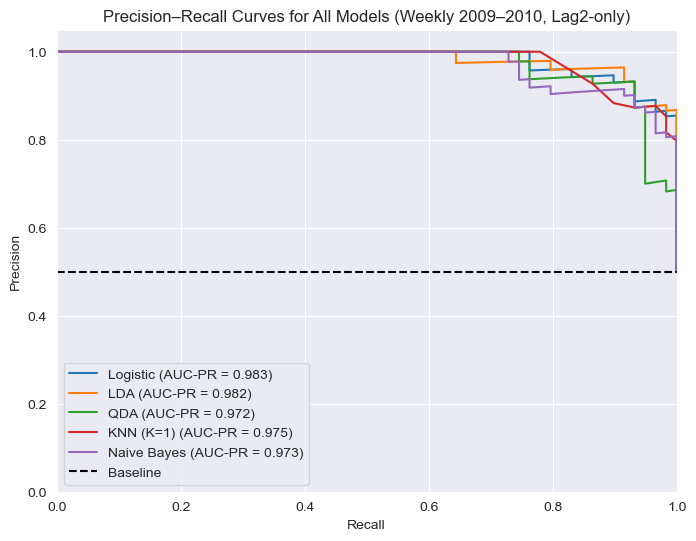

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

probs_log = logit.predict_proba(X_test)[:, 1]
probs_lda = lda.predict_proba(X_test)[:, 1]
probs_qda = qda.predict_proba(X_test)[:, 1]
probs_knn = knn.predict_proba(X_test)[:, 1]
probs_nb  = nb.predict_proba(X_test)[:, 1]

models = {
    "Logistic": probs_log,
    "LDA": probs_lda,
    "QDA": probs_qda,
    "KNN (K=1)": probs_knn,
    "Naive Bayes": probs_nb
}

plt.figure(figsize=(8,6))
ap_scores = {}
roc_scores = {}

for name, probs in models.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    auc_roc = roc_auc_score(y_test, probs)
    ap_scores[name] = ap
    roc_scores[name] = auc_roc
    plt.plot(recall, precision, label=f"{name} (AUC-PR = {ap:.3f})")

baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='k', linestyles='--', label='Baseline')

plt.title("Precision–Recall Curves for All Models (Weekly 2009–2010, Lag2-only)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0,1)
plt.ylim(0,1.05)
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

### (14j) Rank these models based on their AUC values.

In [40]:
ranked = sorted(ap_scores.items(), key=lambda x: x[1], reverse=True)
print("\nModel Ranking by AUC-PR (Precision–Recall Area Under Curve):")
for i, (name, ap) in enumerate(ranked, 1):
    print(f"{i}. {name:15s}  AUC-PR = {ap:.3f}  | ROC-AUC = {roc_scores[name]:.3f}")



Model Ranking by AUC-PR (Precision–Recall Area Under Curve):
1. Logistic         AUC-PR = 0.983  | ROC-AUC = 0.982
2. LDA              AUC-PR = 0.982  | ROC-AUC = 0.983
3. KNN (K=1)        AUC-PR = 0.975  | ROC-AUC = 0.978
4. Naive Bayes      AUC-PR = 0.973  | ROC-AUC = 0.972
5. QDA              AUC-PR = 0.972  | ROC-AUC = 0.966


The best is the logistic and LDA since they are closest to 1